# PrototypeNine-v1.5 — VLM Quality Assurance Filtering (Local Free VLM)

This notebook reads the generated images, masks, and metadata from the generation notebook, then runs a **local** vision-language model (VLM) as a second-stage QA filter.

Updated design:
- **No external API**
- local Hugging Face model loading
- object-level judging using cropped inserted objects
- **more training-focused / less overly strict prompt**
- **incremental saving** after each image
- **resume support** if a long run stops halfway
- image-level accept/reject derived from object-level verdicts

Recommended default model on a single 4090:
- `Qwen/Qwen2.5-VL-3B-Instruct`

If you have enough memory and want stronger quality judgement, you can switch to:
- `Qwen/Qwen2.5-VL-7B-Instruct`


In [16]:
# -----------------------
# Section 0 - Imports + config
# -----------------------
import os, json, shutil
from pathlib import Path

# Avoid intermittent Hugging Face Xet reconstruction errors while downloading large model shards.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch

# Faster matmul on RTX 4090
torch.set_float32_matmul_precision("high")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

BASE_DIR = Path.cwd()
EXPERIMENT_NAME = "PrototypeNine_v1_5"

# Source dataset stays the same as the old notebook
source_root         = BASE_DIR / "output" / EXPERIMENT_NAME
source_image_dir    = source_root / "images"
source_label_dir    = source_root / "labels_yolo"
source_mask_dir     = source_root / "masks"
source_metadata_dir = source_root / "metadata"

# New isolated run folders so this notebook does not interfere with the old one
QA_RUN_NAME = f"{EXPERIMENT_NAME}_vlm_qa_local_v3_balanced"
qa_root = BASE_DIR / "output" / QA_RUN_NAME
qa_debug_dir = qa_root / "debug"
filtered_root = BASE_DIR / "output" / f"{EXPERIMENT_NAME}_vlm_filtered_local_v3_balanced"

filtered_image_dir    = filtered_root / "images"
filtered_label_dir    = filtered_root / "labels_yolo"
filtered_mask_dir     = filtered_root / "masks"
filtered_metadata_dir = filtered_root / "metadata"

for _d in [
    qa_root, qa_debug_dir,
    filtered_root, filtered_image_dir, filtered_label_dir, filtered_mask_dir, filtered_metadata_dir
]:
    _d.mkdir(parents=True, exist_ok=True)

object_csv_path   = qa_root / "qa_results_per_object.csv"
image_csv_path    = qa_root / "qa_results_per_image.csv"
manifest_csv_path = filtered_root / "manifest.csv"

CSV_SCHEMAS = {
    str(object_csv_path): [
        "image_stem", "object_index", "class_name", "bbox_xyxy", "mask_relpath",
        "generation_prompt", "reference_filename", "verdict", "confidence",
        "defect_type", "reason", "raw_response", "local_scene_used", "hard_reject_flag",
    ],
    str(image_csv_path): [
        "image_stem", "image_relpath", "label_relpath", "metadata_relpath",
        "image_verdict", "reject_count", "object_count", "reject_fraction", "hard_reject_count",
    ],
    str(manifest_csv_path): [
        "image_stem", "accepted_object_count", "image_relpath", "label_relpath", "metadata_relpath",
    ],
}

# ---------- RUN CONTROL ----------
# Set True only if you want to delete this notebook's previous QA CSVs and filtered dataset and start over.
RESET_PREVIOUS_RESULTS = False

# If True, already-processed images are skipped automatically.
RESUME_IF_OUTPUTS_EXIST = True

# Copy accepted files immediately after each image is judged.
SAVE_ACCEPTED_FILES_IMMEDIATELY = True

# ---------- LOCAL VLM ----------
# Recommended start on a single 4090:
#   Qwen/Qwen2.5-VL-3B-Instruct
# Stronger but heavier:
#   Qwen/Qwen2.5-VL-7B-Instruct
MODEL_NAME = os.environ.get("LOCAL_VLM_MODEL_NAME", "Qwen/Qwen2.5-VL-3B-Instruct")

# Set to True only if you installed bitsandbytes and want lower memory usage.
LOAD_IN_4BIT = False

# bfloat16 is a good default on RTX 4090.
TORCH_DTYPE = "bfloat16"   # "bfloat16" | "float16" | "float32"
ATTN_IMPLEMENTATION = "sdpa"

# Context policy
# The old notebook only judged the white-background isolated crop.
# This version also sends a local scene crop to help catch bad blending / placement.
USE_LOCAL_SCENE_CROP = True
USE_REFERENCE_IMAGE = False          # Keep False by default for speed. Enable if you want a stricter comparison pass.
USE_FULL_IMAGE_AS_CONTEXT = False    # Optional extra context; slower, so False by default.
CROP_PAD_PX = 12
LOCAL_SCENE_PAD_PX = 28

# Resize caps for VLM efficiency
MAX_CROP_SIDE = 512
MAX_LOCAL_SCENE_SIDE = 576
MAX_REF_SIDE = 512
MAX_FULL_IMAGE_SIDE = 768

# Short answers are faster and enough for this task
MAX_NEW_TOKENS = 120
DO_SAMPLE = False

# Balanced stricter policy:
# - stricter than the old notebook
# - but not so strict that one borderline object automatically rejects the whole image
MIN_ACCEPT_CONFIDENCE = 0.68
LOW_CONFIDENCE_REJECT = 0.55

IMAGE_REJECT_MODE = "balanced"       # "balanced", "fraction", or "any"
MAX_REJECT_FRACTION = 0.25           # reject image if >25% objects are rejected in fraction mode
MIN_REJECT_OBJECTS = 2               # need at least 2 rejected objects for fraction mode
MAX_REJECT_OBJECTS_ABSOLUTE = 3      # reject image if 3 or more objects are rejected
MAX_HARD_REJECTS_PER_IMAGE = 2       # reject image if >=2 severe failures are found

# Severe failures that should count more strongly
HARD_REJECT_DEFECTS = {"missing", "class_mismatch", "shape", "artifact"}
HARD_REJECT_CONFIDENCE = 0.72

# Optional: limit for debugging
MAX_IMAGES = 150  # e.g., 10

if RESET_PREVIOUS_RESULTS:
    for p in [object_csv_path, image_csv_path, manifest_csv_path]:
        if p.exists():
            p.unlink()
    for d in [filtered_image_dir, filtered_label_dir, filtered_mask_dir, filtered_metadata_dir]:
        if d.exists():
            for f in d.glob("*"):
                if f.is_file():
                    f.unlink()

print("[INFO] source_root:", source_root)
print("[INFO] qa_root:", qa_root)
print("[INFO] filtered_root:", filtered_root)
print("[INFO] MODEL_NAME:", MODEL_NAME)
print("[INFO] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[INFO] GPU:", torch.cuda.get_device_name(0))


[INFO] source_root: /workspace/RD2/output/PrototypeNine_v1_5
[INFO] qa_root: /workspace/RD2/output/PrototypeNine_v1_5_vlm_qa_local_v3_balanced
[INFO] filtered_root: /workspace/RD2/output/PrototypeNine_v1_5_vlm_filtered_local_v3_balanced
[INFO] MODEL_NAME: Qwen/Qwen2.5-VL-3B-Instruct
[INFO] CUDA available: True
[INFO] GPU: NVIDIA GeForce RTX 4090


In [17]:
# -----------------------
# Section 1 - Load local VLM + helpers
# -----------------------
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

def resolve_torch_dtype(name: str):
    name = str(name).lower().strip()
    if name == "bfloat16":
        return torch.bfloat16
    if name == "float16":
        return torch.float16
    return torch.float32

def load_local_vlm(model_name: str, load_in_4bit: bool = False):
    dtype = resolve_torch_dtype(TORCH_DTYPE)
    extra_kwargs = {}

    if torch.cuda.is_available():
        extra_kwargs["device_map"] = "auto"
        extra_kwargs["attn_implementation"] = ATTN_IMPLEMENTATION
    else:
        extra_kwargs["device_map"] = None

    if load_in_4bit:
        from transformers import BitsAndBytesConfig
        extra_kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=dtype,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
        )
        extra_kwargs["torch_dtype"] = dtype
    else:
        extra_kwargs["torch_dtype"] = dtype

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_name,
        **extra_kwargs
    )
    model.eval()

    try:
        model.generation_config.do_sample = DO_SAMPLE
        if hasattr(model.generation_config, "temperature"):
            model.generation_config.temperature = None
        if hasattr(model.generation_config, "top_p"):
            model.generation_config.top_p = None
        if hasattr(model.generation_config, "top_k"):
            model.generation_config.top_k = None
    except Exception:
        pass

    processor = AutoProcessor.from_pretrained(model_name)
    return model, processor

model, processor = load_local_vlm(MODEL_NAME, load_in_4bit=LOAD_IN_4BIT)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def crop_with_padding(img: Image.Image, bbox_xyxy, pad=12):
    x1, y1, x2, y2 = bbox_xyxy
    x1 = max(0, int(x1) - pad)
    y1 = max(0, int(y1) - pad)
    x2 = min(img.width, int(x2) + pad)
    y2 = min(img.height, int(y2) + pad)
    return img.crop((x1, y1, x2, y2))

def crop_masked_object(img: Image.Image, mask_img: Image.Image, bbox_xyxy, pad=12, bg_color=(255, 255, 255)):
    crop_img = crop_with_padding(img, bbox_xyxy, pad=pad).convert("RGB")
    crop_mask = crop_with_padding(mask_img.convert("L"), bbox_xyxy, pad=pad)
    bg = Image.new("RGB", crop_img.size, bg_color)
    return Image.composite(crop_img, bg, crop_mask)

def crop_local_scene(img: Image.Image, bbox_xyxy, pad=28):
    return crop_with_padding(img, bbox_xyxy, pad=pad).convert("RGB")

def resize_longest_side(img: Image.Image, max_side: int):
    img = img.convert("RGB")
    w, h = img.size
    if max(w, h) <= max_side:
        return img
    scale = max_side / float(max(w, h))
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return img.resize((new_w, new_h), Image.LANCZOS)

def build_user_prompt(class_name: str, generation_prompt: str, include_local: bool, include_ref: bool, include_full: bool) -> str:
    notes = []
    if include_full:
        notes.append("Image 1 is the full generated scene for context.")
    if include_local:
        notes.append("The next image is a local scene crop around the object, showing the real surrounding context and blend boundaries.")
    notes.append("The next image is the isolated masked object crop on white, useful for judging object structure and class appearance.")
    if include_ref:
        notes.append("The final image is a reference example of the intended object class.")
    image_notes = " ".join(notes)

    return f"""
You are evaluating whether a synthetic object is reliable enough for object-detection training.

{image_notes}

Target object class: {class_name}
Original generation prompt: {generation_prompt}

Use a balanced but quality-focused standard:
- Accept clearly usable objects.
- Reject objects with meaningful defects that would teach the detector the wrong appearance.
- Minor imperfections can still be acceptable if the object remains structurally plausible and visually useful.

Reject if one or more of these are clearly true:
- the object is not clearly recognizable as the target class
- the object shape is badly distorted, broken, duplicated, melted, or incomplete
- the local blending into the scene looks clearly wrong or misleading
- strong inpainting artifacts, smearing, halos, or ghosting are visible
- the object is mostly missing or severely corrupted
- the object clearly does not match the intended class

Accept if the object is recognizable, class-correct, structurally plausible, and useful for training even if it has minor non-critical flaws.

Return JSON only with this exact schema:
{{
  "verdict": "accept" or "reject",
  "confidence": 0.0,
  "defect_type": "none|shape|blend|artifact|missing|class_mismatch|scale|texture|other",
  "reason": "short explanation"
}}
""".strip()

def parse_json_response(text: str):
    text = str(text).strip()
    if "```" in text:
        parts = text.split("```")
        for part in parts:
            part = part.strip()
            if part.startswith("{") and part.endswith("}"):
                text = part
                break
            if part.startswith("json"):
                cand = part[4:].strip()
                if cand.startswith("{") and cand.endswith("}"):
                    text = cand
                    break

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        text = text[start:end+1]

    data = json.loads(text)
    verdict = str(data.get("verdict", "")).strip().lower()
    if verdict not in {"accept", "reject"}:
        verdict = "reject"
    data["verdict"] = verdict
    data["confidence"] = float(data.get("confidence", 0.0))
    data["defect_type"] = str(data.get("defect_type", "other")).strip().lower()
    data["reason"] = str(data.get("reason", "")).strip()
    return data

def move_inputs_to_model_device(inputs, model):
    model_device = next(model.parameters()).device
    moved = {}
    for k, v in inputs.items():
        if hasattr(v, "to"):
            try:
                moved[k] = v.to(model_device, non_blocking=True)
            except TypeError:
                moved[k] = v.to(model_device)
        else:
            moved[k] = v
    return moved

def normalize_object_verdict(parsed):
    parsed = dict(parsed)
    verdict = str(parsed.get("verdict", "reject")).lower()
    confidence = float(parsed.get("confidence", 0.0))
    defect_type = str(parsed.get("defect_type", "other")).lower()

    hard_reject = defect_type in HARD_REJECT_DEFECTS and confidence >= HARD_REJECT_CONFIDENCE

    if confidence < LOW_CONFIDENCE_REJECT:
        verdict = "reject"

    if hard_reject:
        verdict = "reject"

    parsed["verdict"] = verdict
    parsed["confidence"] = confidence
    parsed["defect_type"] = defect_type
    parsed["hard_reject_flag"] = bool(hard_reject)
    return parsed

@torch.inference_mode()
def judge_object_with_local_vlm(object_crop: Image.Image, class_name: str, generation_prompt: str,
                                reference_img=None, full_image=None, local_scene_crop=None):
    images = []
    content = []

    include_full = USE_FULL_IMAGE_AS_CONTEXT and (full_image is not None)
    if include_full:
        full_image = resize_longest_side(full_image, MAX_FULL_IMAGE_SIDE)
        images.append(full_image)
        content.append({"type": "image"})

    include_local = USE_LOCAL_SCENE_CROP and (local_scene_crop is not None)
    if include_local:
        local_scene_crop = resize_longest_side(local_scene_crop, MAX_LOCAL_SCENE_SIDE)
        images.append(local_scene_crop)
        content.append({"type": "image"})

    object_crop = resize_longest_side(object_crop, MAX_CROP_SIDE)
    images.append(object_crop)
    content.append({"type": "image"})

    include_ref = False
    if USE_REFERENCE_IMAGE and reference_img is not None:
        reference_img = resize_longest_side(reference_img, MAX_REF_SIDE)
        images.append(reference_img)
        content.append({"type": "image"})
        include_ref = True

    content.append({
        "type": "text",
        "text": build_user_prompt(
            class_name,
            generation_prompt,
            include_local=include_local,
            include_ref=include_ref,
            include_full=include_full
        )
    })

    messages = [{"role": "user", "content": content}]
    chat_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = processor(
        text=[chat_text],
        images=images,
        padding=True,
        return_tensors="pt"
    )
    inputs = move_inputs_to_model_device(inputs, model)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        use_cache=True,
    )
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    raw_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0]

    parsed = parse_json_response(raw_text)
    parsed["raw_response"] = raw_text
    parsed = normalize_object_verdict(parsed)
    return parsed

def aggregate_image_verdict(object_rows):
    rejects = [r for r in object_rows if (r["verdict"] == "reject") or (float(r.get("confidence", 0.0)) < MIN_ACCEPT_CONFIDENCE)]
    reject_count = len(rejects)
    object_count = max(1, len(object_rows))
    reject_fraction = reject_count / float(object_count)
    hard_reject_count = sum(1 for r in object_rows if bool(r.get("hard_reject_flag", False)))

    if IMAGE_REJECT_MODE == "any":
        image_verdict = "reject" if reject_count > 0 else "accept"
    elif IMAGE_REJECT_MODE == "fraction":
        image_verdict = "reject" if ((reject_count >= MIN_REJECT_OBJECTS) and (reject_fraction > MAX_REJECT_FRACTION)) else "accept"
    else:
        # balanced mode:
        # reject if too many bad objects overall, or too many severe failures
        image_verdict = "accept"
        if hard_reject_count >= MAX_HARD_REJECTS_PER_IMAGE:
            image_verdict = "reject"
        elif reject_count >= MAX_REJECT_OBJECTS_ABSOLUTE:
            image_verdict = "reject"
        elif (reject_count >= MIN_REJECT_OBJECTS) and (reject_fraction > MAX_REJECT_FRACTION):
            image_verdict = "reject"

    return {
        "image_verdict": image_verdict,
        "reject_count": reject_count,
        "object_count": object_count,
        "reject_fraction": reject_fraction,
        "hard_reject_count": hard_reject_count,
    }

def append_rows_to_csv(rows, csv_path: Path):
    if not rows:
        return
    df = pd.DataFrame(rows)
    columns = CSV_SCHEMAS.get(str(csv_path), list(df.columns))
    df = df.reindex(columns=columns)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    write_header = (not csv_path.exists()) or csv_path.stat().st_size == 0
    if not write_header:
        needs_migration = False
        try:
            existing_header = pd.read_csv(csv_path, nrows=0)
            needs_migration = list(existing_header.columns) != columns
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            needs_migration = True

        if needs_migration:
            try:
                existing = pd.read_csv(csv_path)
            except pd.errors.EmptyDataError:
                existing = pd.DataFrame(columns=columns)
            except pd.errors.ParserError:
                existing = pd.read_csv(csv_path, names=columns, header=0, engine="python")

            if not set(existing.columns).intersection(columns):
                existing = pd.read_csv(csv_path, names=columns, header=None)
            existing = existing.dropna(how="all").reindex(columns=columns)
            existing.to_csv(csv_path, index=False)

    df.to_csv(csv_path, mode="w" if write_header else "a", header=write_header, index=False)

def safe_copy2(src: Path, dst: Path):
    if not dst.exists():
        shutil.copy2(src, dst)

def copy_accepted_bundle(meta: dict, metadata_relpath: str):
    src_img = source_root / meta["image_relpath"]
    src_lbl = source_root / meta["label_relpath"]
    src_meta = source_root / metadata_relpath

    safe_copy2(src_img, filtered_image_dir / src_img.name)
    safe_copy2(src_lbl, filtered_label_dir / src_lbl.name)
    safe_copy2(src_meta, filtered_metadata_dir / src_meta.name)

    for obj in meta["objects"]:
        src_mask = source_root / obj["mask_relpath"]
        safe_copy2(src_mask, filtered_mask_dir / src_mask.name)

    manifest_row = {
        "image_stem": meta["image_stem"],
        "accepted_object_count": len(meta["objects"]),
        "image_relpath": f"images/{src_img.name}",
        "label_relpath": f"labels_yolo/{src_lbl.name}",
        "metadata_relpath": f"metadata/{src_meta.name}",
    }
    append_rows_to_csv([manifest_row], manifest_csv_path)

def load_processed_stems():
    stems = set()
    if RESUME_IF_OUTPUTS_EXIST and image_csv_path.exists():
        try:
            prev = pd.read_csv(image_csv_path)
            if "image_stem" in prev.columns:
                stems = set(prev["image_stem"].astype(str).tolist())
        except Exception:
            pass
    return stems

print("[INFO] Local VLM loaded successfully.")
print("[INFO] Model device:", next(model.parameters()).device)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

[INFO] Local VLM loaded successfully.
[INFO] Model device: cuda:0


Local scene crop:


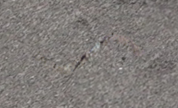

Masked object crop:


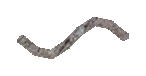

Sample class: rope
Sample prompt: a tangled rope on the shoreline, top-down drone view, photo-realistic

[DEBUG] Sample VLM verdict:
{
  "verdict": "reject",
  "confidence": 0.8,
  "defect_type": "shape",
  "reason": "The object appears to be a distorted and incomplete representation of a rope, making it difficult to recognize as the target class.",
  "raw_response": "```json\n{\n  \"verdict\": \"reject\",\n  \"confidence\": 0.8,\n  \"defect_type\": \"shape\",\n  \"reason\": \"The object appears to be a distorted and incomplete representation of a rope, making it difficult to recognize as the target class.\"\n}\n```",
  "hard_reject_flag": true
}


In [18]:
# -----------------------
# Section 2 - Optional debug on a single object
# -----------------------
meta_files = sorted(source_metadata_dir.glob("*.json"))
if not meta_files:
    raise FileNotFoundError(f"No metadata files found in {source_metadata_dir}")

sample_meta = load_json(meta_files[5])
sample_obj = sample_meta["objects"][5]

img = Image.open(source_root / sample_meta["image_relpath"]).convert("RGB")
mask = Image.open(source_root / sample_obj["mask_relpath"]).convert("L")
obj_crop = crop_masked_object(img, mask, sample_obj["bbox_xyxy"], pad=CROP_PAD_PX)
local_scene_crop = crop_local_scene(img, sample_obj["bbox_xyxy"], pad=LOCAL_SCENE_PAD_PX)

ref_img = None
ref_path = sample_obj.get("reference_path")
if USE_REFERENCE_IMAGE and ref_path and Path(ref_path).exists():
    ref_img = Image.open(ref_path).convert("RGB")

print("Local scene crop:")
display(local_scene_crop)
print("Masked object crop:")
display(obj_crop)
print("Sample class:", sample_obj["class_name"])
print("Sample prompt:", sample_obj["generation_prompt"])

sample_judge = judge_object_with_local_vlm(
    object_crop=obj_crop,
    local_scene_crop=local_scene_crop,
    class_name=sample_obj["class_name"],
    generation_prompt=sample_obj["generation_prompt"],
    reference_img=ref_img,
    full_image=img,
)

print("\n[DEBUG] Sample VLM verdict:")
print(json.dumps(sample_judge, indent=2))


In [19]:

# -----------------------
# Section 3 - Run local VLM QA over the generated dataset (incremental save / resume-safe)
# -----------------------
processed_stems = load_processed_stems()

meta_files = sorted(source_metadata_dir.glob("*.json"))
if MAX_IMAGES is not None:
    meta_files = meta_files[:MAX_IMAGES]

if processed_stems:
    meta_files = [p for p in meta_files if p.stem not in processed_stems]

print(f"[INFO] Images already processed: {len(processed_stems)}")
print(f"[INFO] Images remaining this run: {len(meta_files)}")

processed_this_run = 0

for meta_path in tqdm(meta_files, desc="Local VLM QA"):
    meta = load_json(meta_path)
    img_path = source_root / meta["image_relpath"]
    full_img = Image.open(img_path).convert("RGB")

    per_image_object_rows = []

    for obj in meta["objects"]:
        mask_path = source_root / obj["mask_relpath"]
        mask_img = Image.open(mask_path).convert("L")

        object_crop = crop_masked_object(full_img, mask_img, obj["bbox_xyxy"], pad=CROP_PAD_PX)
        local_scene_crop = crop_local_scene(full_img, obj["bbox_xyxy"], pad=LOCAL_SCENE_PAD_PX)

        ref_img = None
        ref_path = obj.get("reference_path")
        if USE_REFERENCE_IMAGE and ref_path and Path(ref_path).exists():
            ref_img = Image.open(ref_path).convert("RGB")

        try:
            judge = judge_object_with_local_vlm(
                object_crop=object_crop,
                class_name=obj["class_name"],
                generation_prompt=obj["generation_prompt"],
                reference_img=ref_img,
                full_image=full_img,
                local_scene_crop=local_scene_crop,
            )
        except Exception as e:
            judge = {
                "verdict": "reject",
                "confidence": 0.0,
                "defect_type": "model_error",
                "reason": f"Local VLM failed: {e}",
                "raw_response": "",
                "hard_reject_flag": True,
            }

        row = {
            "image_stem": meta["image_stem"],
            "object_index": obj["object_index"],
            "class_name": obj["class_name"],
            "bbox_xyxy": json.dumps(obj["bbox_xyxy"]),
            "mask_relpath": obj["mask_relpath"],
            "generation_prompt": obj["generation_prompt"],
            "reference_filename": obj.get("reference_filename"),
            "verdict": judge["verdict"],
            "confidence": judge["confidence"],
            "defect_type": judge["defect_type"],
            "reason": judge["reason"],
            "raw_response": judge.get("raw_response", ""),
            "local_scene_used": USE_LOCAL_SCENE_CROP,
            "hard_reject_flag": bool(judge.get("hard_reject_flag", False)),
        }
        per_image_object_rows.append(row)

        # free small temporaries
        del mask_img, object_crop, local_scene_crop, ref_img

    image_summary = aggregate_image_verdict(per_image_object_rows)
    image_row = {
        "image_stem": meta["image_stem"],
        "image_relpath": meta["image_relpath"],
        "label_relpath": meta["label_relpath"],
        "metadata_relpath": str(meta_path.relative_to(source_root)),
        "image_verdict": image_summary["image_verdict"],
        "reject_count": image_summary["reject_count"],
        "object_count": image_summary["object_count"],
        "reject_fraction": image_summary["reject_fraction"],
        "hard_reject_count": image_summary["hard_reject_count"],
    }

    # Save immediately after each image
    append_rows_to_csv(per_image_object_rows, object_csv_path)
    append_rows_to_csv([image_row], image_csv_path)

    if SAVE_ACCEPTED_FILES_IMMEDIATELY and image_row["image_verdict"] == "accept":
        copy_accepted_bundle(meta, image_row["metadata_relpath"])

    processed_this_run += 1

    # periodic cleanup
    del full_img, per_image_object_rows, image_summary, image_row, meta
    if torch.cuda.is_available() and (processed_this_run % 20 == 0):
        torch.cuda.empty_cache()

print("[INFO] Incremental VLM QA run completed.")
print("[INFO] Wrote/updated:", object_csv_path)
print("[INFO] Wrote/updated:", image_csv_path)

if image_csv_path.exists():
    display(pd.read_csv(image_csv_path).tail())
if object_csv_path.exists():
    display(pd.read_csv(object_csv_path).tail())


[INFO] Images already processed: 0
[INFO] Images remaining this run: 150


Local VLM QA: 100%|██████████| 150/150 [2:31:42<00:00, 60.69s/it] 

[INFO] Incremental VLM QA run completed.
[INFO] Wrote/updated: /workspace/RD2/output/PrototypeNine_v1_5_vlm_qa_local_v3_balanced/qa_results_per_object.csv
[INFO] Wrote/updated: /workspace/RD2/output/PrototypeNine_v1_5_vlm_qa_local_v3_balanced/qa_results_per_image.csv


,image_stem,image_relpath,label_relpath,metadata_relpath,image_verdict,reject_count,object_count,reject_fraction,hard_reject_count
145,St_George_s_Beach_with_plastic_20251114110828_...,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...,accept,0,10,0.000000,0
146,St_George_s_Beach_with_plastic_20251114110828_...,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...,reject,3,13,0.230769,3
147,St_George_s_Beach_with_plastic_20251114110828_...,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...,accept,1,9,0.111111,1
148,St_George_s_Beach_with_plastic_20251114110828_...,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...,accept,1,9,0.111111,1
149,St_George_s_Beach_with_plastic_20251114110828_...,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...,accept,1,10,0.100000,1


,image_stem,object_index,class_name,bbox_xyxy,mask_relpath,generation_prompt,reference_filename,verdict,confidence,defect_type,reason,raw_response,local_scene_used,hard_reject_flag
1492,St_George_s_Beach_with_plastic_20251114110828_...,5,rope,"[428, 460, 542, 565]",masks/St_George_s_Beach_with_plastic_202511141...,"a partially coiled rope with loose ends, top-d...",rope_03.png,accept,0.85,none,"The object is clearly recognizable as a rope, ...","```json\n{\n ""verdict"": ""accept"",\n ""confide...",True,False
1493,St_George_s_Beach_with_plastic_20251114110828_...,6,plastic_bottles,"[261, 451, 411, 533]",masks/St_George_s_Beach_with_plastic_202511141...,"a plastic jug lying on the shoreline, top-down...",plastic_bottle_19.png,reject,0.80,class_mismatch,"The object appears to be a plastic bottle, but...","```json\n{\n ""verdict"": ""reject"",\n ""confide...",True,True
1494,St_George_s_Beach_with_plastic_20251114110828_...,7,plastic_bottles,"[215, 79, 359, 155]",masks/St_George_s_Beach_with_plastic_202511141...,"a crushed plastic bottle on sand, top-down dro...",plastic_bottle_18.png,accept,0.80,blend,"The object blends slightly into the sand, whic...","```json\n{\n ""verdict"": ""accept"",\n ""confide...",True,False
1495,St_George_s_Beach_with_plastic_20251114110828_...,8,rope,"[397, 325, 463, 407]",masks/St_George_s_Beach_with_plastic_202511141...,a weathered rope strand lying on the shoreline...,rope_19.png,accept,0.85,blend,"The rope appears to blend well with the sand, ...","```json\n{\n ""verdict"": ""accept"",\n ""confide...",True,False
1496,St_George_s_Beach_with_plastic_20251114110828_...,9,rope,"[173, 349, 239, 515]",masks/St_George_s_Beach_with_plastic_202511141...,"a faded rope lying on sand, top-down drone vie...",rope_06.png,accept,0.85,blend,The rope appears to blend well with the sandy ...,"```json\n{\n ""verdict"": ""accept"",\n ""confide...",True,False


In [20]:

# -----------------------
# Section 4 - Summary of accepted / rejected dataset after incremental save
# -----------------------
if image_csv_path.exists():
    image_df = pd.read_csv(image_csv_path)
    accepted = image_df[image_df["image_verdict"] == "accept"].copy()
    rejected = image_df[image_df["image_verdict"] != "accept"].copy()

    print("[INFO] Accepted images:", len(accepted))
    print("[INFO] Rejected images:", len(rejected))
    print("[INFO] QA CSV:", image_csv_path)

    if manifest_csv_path.exists():
        accepted_manifest_df = pd.read_csv(manifest_csv_path)
        print("[INFO] Filtered dataset root:", filtered_root)
        display(accepted_manifest_df.tail())
    else:
        print("[INFO] No accepted manifest yet:", manifest_csv_path)
else:
    print("[INFO] No QA results found yet. Run Section 3 first.")


[INFO] Accepted images: 66
[INFO] Rejected images: 84
[INFO] QA CSV: /workspace/RD2/output/PrototypeNine_v1_5_vlm_qa_local_v3_balanced/qa_results_per_image.csv
[INFO] Filtered dataset root: /workspace/RD2/output/PrototypeNine_v1_5_vlm_filtered_local_v3_balanced


,image_stem,accepted_object_count,image_relpath,label_relpath,metadata_relpath
61,St_George_s_Beach_with_plastic_20251114110805_...,10,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...
62,St_George_s_Beach_with_plastic_20251114110828_...,10,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...
63,St_George_s_Beach_with_plastic_20251114110828_...,9,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...
64,St_George_s_Beach_with_plastic_20251114110828_...,9,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...
65,St_George_s_Beach_with_plastic_20251114110828_...,10,images/St_George_s_Beach_with_plastic_20251114...,labels_yolo/St_George_s_Beach_with_plastic_202...,metadata/St_George_s_Beach_with_plastic_202511...


## Local setup notes

Install the main packages before running this notebook:

```bash
pip install -U torch torchvision torchaudio
pip install -U transformers accelerate pillow pandas tqdm
```

Optional for lower VRAM:

```bash
pip install bitsandbytes
```

Recommended defaults on a single 4090:
- start with `Qwen/Qwen2.5-VL-3B-Instruct`
- keep `USE_REFERENCE_IMAGE = False` at first for speed
- keep `USE_FULL_IMAGE_AS_CONTEXT = False`
- only switch to `Qwen/Qwen2.5-VL-7B-Instruct` after the 3B workflow is stable
- this notebook now saves results **image by image** and supports **resume**
